# Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

np.random.seed(42)

Logistic regression predicts a probability : $\hat{p} = P(y = 1 \mid x)$
</br>

To do so, it first computes a linear combination of the input features, just like linear regression. Then it applies the logistic function to transform this value into a probability.

The logistic, also noted σ() is a sigmoid function that outputs a value between 0 and 1:
$$
\sigma(t) = \frac{1}{1 + e^{-t}}
$$
</br>
By default, when the estimated probability is greater than or equal to 50% the logistic regression outputs a 1, else it is a 0.
</br>
Also, the vectorized form looks like this: p_pred = σ(X θ).

# Generating a synthetic dataset

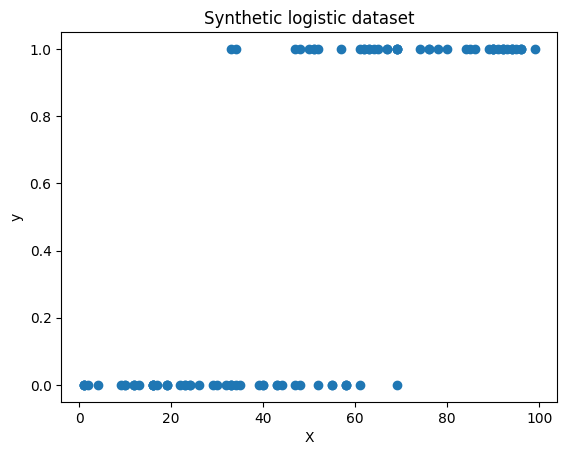

In [5]:
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))
noise = np.random.normal(0, 1, size=(n_sample, 1))

z = 0.12 * X - 6 + noise

# sigmoid
p = 1 / (1 + np.exp(-z))

# random 0 or 1
y = np.random.binomial(1, p).ravel().reshape(-1, 1)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic logistic dataset")
plt.show()

# Training

## Log loss cost function

If the real class is 0, we want our model to predict something close to 0, a contrario if the real class is 1 we want the model to predict something close to 1.
</br>
For a single X we can use this cost function c():
</br>
$$
c(\theta) =
\begin{cases}
-\log(p) & \text{if } y = 1 \\
-\log(1 - p) & \text{if } y = 0
\end{cases}
$$
</br>
It is a good representation because it penalizes confident wrong predictions. For example, if the true class is 1 we want the model to predict close to 1.
</br>

So, if the model predicts 0.99, the cost is ${-\log(0.99) \approx 0.01}$, the cost is very low. On the other hand, if the model predicts 0.01, the cost is ${-\log(0.01) \approx 4.6}$, so the cost is much higher. And it is the other way around for the 0 class.

The cost function over all the training set can be written as following:
$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y^{(i)} \log\left(\hat{p}^{(i)}\right)
+
\left(1 - y^{(i)}\right)
\log\left(1 - \hat{p}^{(i)}\right)
\right]
$$

In this formula $(y^{(i)})$ and $(1-y^{(i)})$ act like switches. Since $(y^{(i)})$ is either 0 or 1, only one part of the loss remains active.


So the full log loss formula is just a compact way to write two different cases in one equation as the equation juste above. 
</br>
Despite its scary look it basically is the average cost over all the dataset.

Finally we will compute the gradient using the partial derivative of the cost function for $\theta_j$ :
$$
\frac{\partial}{\partial \theta_j} J(\theta)
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\sigma\left(\theta^T x^{(i)}\right) - y^{(i)}
\right)
x_j^{(i)}
$$

By the way, there is no closed-form equation to minimize $\theta$ like we used for the linear regression, but this cost function is convex so the gradient descent is guaranteed to find the global minimum.

## Training with the gradient descent

In [ ]:
def logistic(z):
    return 1 / (1 + np.exp(-z))

X_b = np.c_[np.ones((n_sample, 1)), X]
learning_rate = 0.001
n_iterations = 100
m = len(X)
cost_history = []
epsilon = 1e-15

theta = np.random.randn(2, 1)

for iteration in range(n_iterations):
    
    p_pred = logistic(X_b @ theta)

    cost = -(1 / m) * np.sum(y * np.log(p_pred + epsilon) + (1 - y) * np.log(1- p_pred + epsilon))
    cost_history.append(cost)

    gradient = (1 / m) * X_b.T @ (p_pred - y)

    theta = theta - learning_rate * gradient


p_pred = logistic(X_b @ theta)


y_predict = (p_pred >= 0.5).astype(int)

array([[1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
    